# UniTalk-ASD vs. AVA-ActiveSpeaker — dataset comparison

Compares the two data sources feeding the windowed pipeline's combined training run
(`scripts/train_windowed_combined.py`): detection-rate/class-balance/track-length statistics,
comparison charts, and sample face crops with detected landmarks overlaid, covering all four
`detected × speaking` combinations for each dataset.

Reads directly from `data/processed/{train,val}/combined_landmarks.csv` (UniTalk-ASD) and
`data/processed_ava/{train,val}/combined_landmarks.csv` (AVA) — the same files
`src/dataset.py`/`src/windowed_dataset.py` train on. These are large files (22-23GB for the two
`train` splits), so statistics use `usecols` to avoid loading landmark columns, and the sample-image
search stops early once enough examples per category are found rather than scanning the whole file.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from PIL import Image

PROJECT_ROOT = Path.cwd().parent
sys.path.append(str(PROJECT_ROOT))
sys.path.append(str(PROJECT_ROOT / "src"))
from config import (
    AVA_PROCESSED_DATASET_DIR,
    AVA_RAW_CLIPS_VIDEOS_DIR,
    DATA_PROCESSED_DIR,
    MOUTH_LANDMARK_INDICES,
    NUM_FACE_LANDMARKS,
    RAW_CLIPS_VIDEOS_DIR,
)

DATASETS = {
    "UniTalk-ASD": {
        "train_csv": DATA_PROCESSED_DIR / "train" / "combined_landmarks.csv",
        "val_csv": DATA_PROCESSED_DIR / "val" / "combined_landmarks.csv",
        "raw_dir": RAW_CLIPS_VIDEOS_DIR,
        "color": "#2a78d6",
    },
    "AVA-ActiveSpeaker": {
        "train_csv": AVA_PROCESSED_DATASET_DIR / "train" / "combined_landmarks.csv",
        "val_csv": AVA_PROCESSED_DATASET_DIR / "val" / "combined_landmarks.csv",
        "raw_dir": AVA_RAW_CLIPS_VIDEOS_DIR,
        "color": "#008300",
    },
}

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"

## 1. Dataset statistics

Frame-level detection rate and class balance, plus track-level (`person_id`) stats — track count and
frame-length distribution. Only `person_id`/`detected`/`target_index` are read (not the 1,434 landmark
columns), so this stays fast even on the 22-23GB `train` files.

In [2]:
def load_lightweight(csv_path: Path) -> pd.DataFrame:
    return pd.read_csv(csv_path, usecols=["person_id", "detected", "target_index"], engine="pyarrow")


def summarize(df: pd.DataFrame) -> dict:
    track_lengths = df.groupby("person_id", sort=False).size()
    return {
        "n_frames": len(df),
        "n_tracks": df["person_id"].nunique(),
        "detected_rate": df["detected"].mean(),
        "speaking_rate": df["target_index"].mean(),
        "mean_track_len": track_lengths.mean(),
        "median_track_len": track_lengths.median(),
        "track_lengths": track_lengths,
    }


stats = {}
for name, cfg in DATASETS.items():
    for split_label, csv_key in (("train", "train_csv"), ("val", "val_csv")):
        print(f"loading {name} / {split_label} ...")
        df = load_lightweight(cfg[csv_key])
        stats[(name, split_label)] = summarize(df)
        del df

summary_table = pd.DataFrame(
    {
        key: {k: v for k, v in s.items() if k != "track_lengths"}
        for key, s in stats.items()
    }
).T
summary_table.index.names = ["dataset", "split"]
summary_table

loading UniTalk-ASD / train ...


loading UniTalk-ASD / val ...


loading AVA-ActiveSpeaker / train ...


loading AVA-ActiveSpeaker / val ...


n_frames  n_tracks  detected_rate  speaking_rate  \
dataset           split                                                      
UniTalk-ASD       train  3001883.0   36791.0       0.510947       0.280427   
                  val     998644.0   11902.0       0.595264       0.205985   
AVA-ActiveSpeaker train  2473790.0   27438.0       0.682684       0.263784   
                  val     768307.0    8015.0       0.670785       0.260953   

                         mean_track_len  median_track_len  
dataset           split                                    
UniTalk-ASD       train       81.592862              55.0  
                  val         83.905562              52.0  
AVA-ActiveSpeaker train       90.159268              65.0  
                  val         95.858640              69.0

## 2. Comparison charts

Categorical color follows the project's existing convention (`src/metrics.py`'s plots): blue
`#2a78d6` and green `#008300`, assigned by dataset identity here (UniTalk-ASD / AVA-ActiveSpeaker)
rather than train/val.

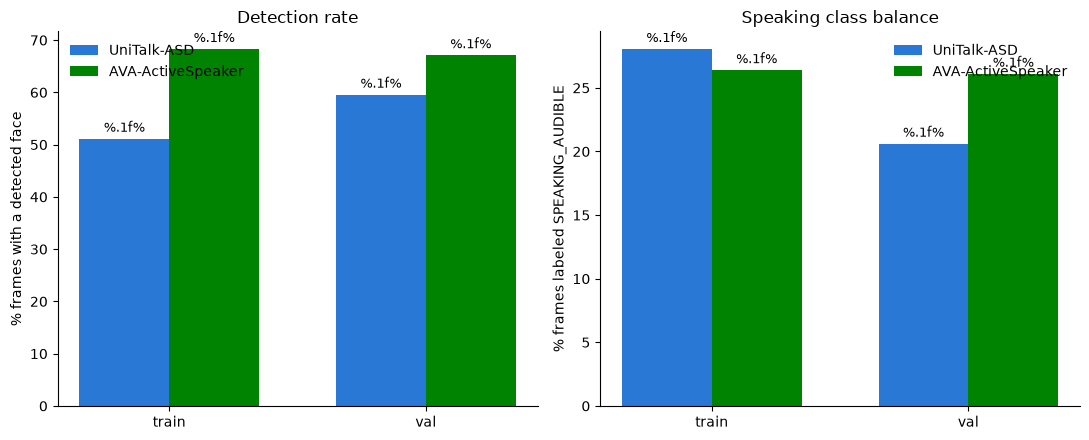

In [3]:
def grouped_bar(metric: str, title: str, ylabel: str, ax, as_pct: bool = True):
    splits = ["train", "val"]
    x = np.arange(len(splits))
    width = 0.35
    for i, (name, cfg) in enumerate(DATASETS.items()):
        values = [stats[(name, s)][metric] for s in splits]
        values = [v * 100 for v in values] if as_pct else values
        offset = (i - 0.5) * width
        bars = ax.bar(x + offset, values, width, label=name, color=cfg["color"])
        ax.bar_label(bars, fmt="%.1f" + ("%" if as_pct else ""), padding=3, fontsize=9)
    ax.set_xticks(x)
    ax.set_xticklabels(splits)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)


fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
grouped_bar("detected_rate", "Detection rate", "% frames with a detected face", axes[0])
grouped_bar("speaking_rate", "Speaking class balance", "% frames labeled SPEAKING_AUDIBLE", axes[1])
fig.tight_layout()
plt.show()

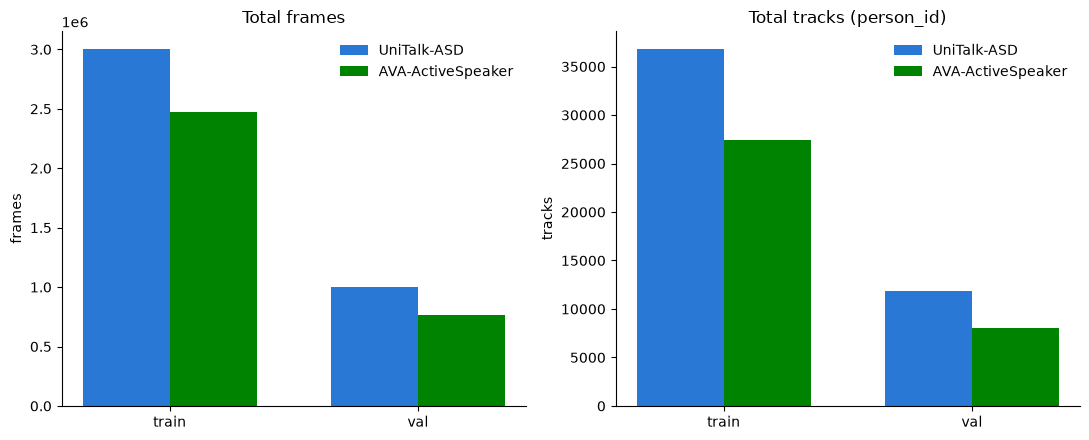

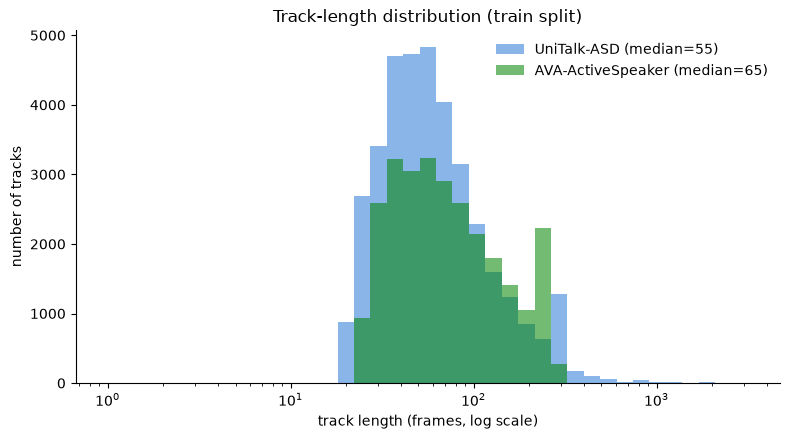

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

x = np.arange(2)
width = 0.35
for i, (name, cfg) in enumerate(DATASETS.items()):
    n_frames = [stats[(name, s)]["n_frames"] for s in ("train", "val")]
    n_tracks = [stats[(name, s)]["n_tracks"] for s in ("train", "val")]
    offset = (i - 0.5) * width
    axes[0].bar(x + offset, n_frames, width, label=name, color=cfg["color"])
    axes[1].bar(x + offset, n_tracks, width, label=name, color=cfg["color"])

for ax, title, ylabel in zip(axes, ["Total frames", "Total tracks (person_id)"], ["frames", "tracks"]):
    ax.set_xticks(x)
    ax.set_xticklabels(["train", "val"])
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.spines[["top", "right"]].set_visible(False)
    ax.legend(frameon=False)

fig.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(8, 4.5))
bins = np.logspace(0, 3.5, 40)
for name, cfg in DATASETS.items():
    lengths = stats[(name, "train")]["track_lengths"]
    ax.hist(lengths, bins=bins, alpha=0.55, label=f"{name} (median={lengths.median():.0f})", color=cfg["color"])
ax.set_xscale("log")
ax.set_xlabel("track length (frames, log scale)")
ax.set_ylabel("number of tracks")
ax.set_title("Track-length distribution (train split)")
ax.spines[["top", "right"]].set_visible(False)
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

## 3. Sample images with landmarks — detected / not detected × speaking / not speaking

Face crops loaded straight from `data/raw{,_ava}/clips_videos/<split>/<video_id>/<person_id>/<image_name>`
(the exact path scripts/process_dataset.py reads from), with the stored landmark columns overlaid —
mesh in green, mouth subset in cyan, matching `PersonLandmarkExtractor`'s own annotation style. Rows
with `detected=False` have null landmark columns, so those are shown as plain crops with a "no face
detected" label instead.

Each `train` CSV is read in chunks (metadata + landmark columns only) and stops as soon as enough
examples are found for all four `detected × speaking` combinations, rather than scanning the whole file.

In [5]:
sys.path.append(str(PROJECT_ROOT / "scripts"))
from extract_landmarks import PersonLandmarkExtractor

# combined_landmarks.csv stores landmarks NORMALIZED (centered on the nose tip,
# scaled by interocular distance — process_dataset.py/process_ava_dataset.py
# both run with normalize=True), and the original pixel-space center/scale
# isn't stored anywhere, so it can't be reconstructed from the CSV. Instead,
# re-run MediaPipe directly on each sample image with normalize=False to get
# real pixel-space landmarks for the overlay — only ~12 images need this, so
# re-detecting is cheap. One shared extractor instance, reused for all images.
landmark_extractor = PersonLandmarkExtractor(normalize=False, save_annotated=False, save_json=False)

N_PER_CATEGORY = 3
META_COLS = ["person_id", "video_id", "image_name", "detected", "target_index"]
CATEGORIES = [(True, 1), (True, 0), (False, 1), (False, 0)]
CATEGORY_LABELS = {
    (True, 1): "detected + SPEAKING",
    (True, 0): "detected + NOT_SPEAKING",
    (False, 1): "not detected + SPEAKING",
    (False, 0): "not detected + NOT_SPEAKING",
}


def sample_examples(csv_path: Path, n_per_category: int = N_PER_CATEGORY, chunksize: int = 20_000, max_chunks: int = 300) -> dict:
    found = {cat: [] for cat in CATEGORIES}
    for i, chunk in enumerate(pd.read_csv(csv_path, usecols=META_COLS, chunksize=chunksize, engine="c")):
        for cat in CATEGORIES:
            if len(found[cat]) >= n_per_category:
                continue
            detected, target = cat
            matches = chunk[(chunk["detected"] == detected) & (chunk["target_index"] == target)]
            needed = n_per_category - len(found[cat])
            found[cat].extend(matches.head(needed).to_dict("records"))
        if all(len(v) >= n_per_category for v in found.values()):
            break
        if i >= max_chunks:
            break
    return found


def image_path(raw_dir: Path, split: str, row: dict) -> Path:
    return raw_dir / split / row["video_id"] / row["person_id"] / row["image_name"]


def draw_landmarks(path: Path) -> tuple[Image.Image, bool]:
    """Re-detects (pixel-space, not normalized) on the actual image and draws
    the result — returns (image, detected). Falls back to the plain image if
    MediaPipe doesn't find a face on this particular re-run (rare given the
    CSV already says detected=True for these rows, but not guaranteed
    identical since detection has some inherent nondeterminism/version drift).
    """
    from PIL import ImageDraw
    record = landmark_extractor.extract_image(path)
    img = Image.open(path).convert("RGB")
    if not record["detected"]:
        return img, False
    draw = ImageDraw.Draw(img)
    mouth_set = set(MOUTH_LANDMARK_INDICES)
    for i, (x, y, _z) in enumerate(record["face_landmarks"]):
        color = (0, 255, 255) if i in mouth_set else (0, 255, 0)
        r = 2 if i in mouth_set else 1
        draw.ellipse([x - r, y - r, x + r, y + r], fill=color)
    return img, True

W0000 00:00:1784383283.916539  717502 face_landmarker_graph.cc:174] Sets FaceBlendshapesGraph acceleration to xnnpack by default.
I0000 00:00:1784383283.997956  717502 gl_context_egl.cc:85] Successfully initialized EGL. Major : 1 Minor: 5
I0000 00:00:1784383284.054160  717553 gl_context.cc:385] GL version: 3.2 (OpenGL ES 3.2 NVIDIA 580.159.03), renderer: NVIDIA RTX PRO 6000 Blackwell Server Edition/PCIe/SSE2


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.


In [6]:
examples = {}
for name, cfg in DATASETS.items():
    print(f"sampling {name} ...")
    examples[name] = sample_examples(cfg["train_csv"])
    for cat, rows in examples[name].items():
        print(f"  {CATEGORY_LABELS[cat]}: found {len(rows)}/{N_PER_CATEGORY}")

sampling UniTalk-ASD ...


  detected + SPEAKING: found 3/3
  detected + NOT_SPEAKING: found 3/3
  not detected + SPEAKING: found 3/3
  not detected + NOT_SPEAKING: found 3/3
sampling AVA-ActiveSpeaker ...


  detected + SPEAKING: found 3/3
  detected + NOT_SPEAKING: found 3/3
  not detected + SPEAKING: found 3/3
  not detected + NOT_SPEAKING: found 3/3


E0000 00:00:1784383286.774232  717553 tensor.cc:404] Tensors are designed for single writes. Multiple writes to a Tensor instance are not supported and may lead to undefined behavior due to lack of synchronization.


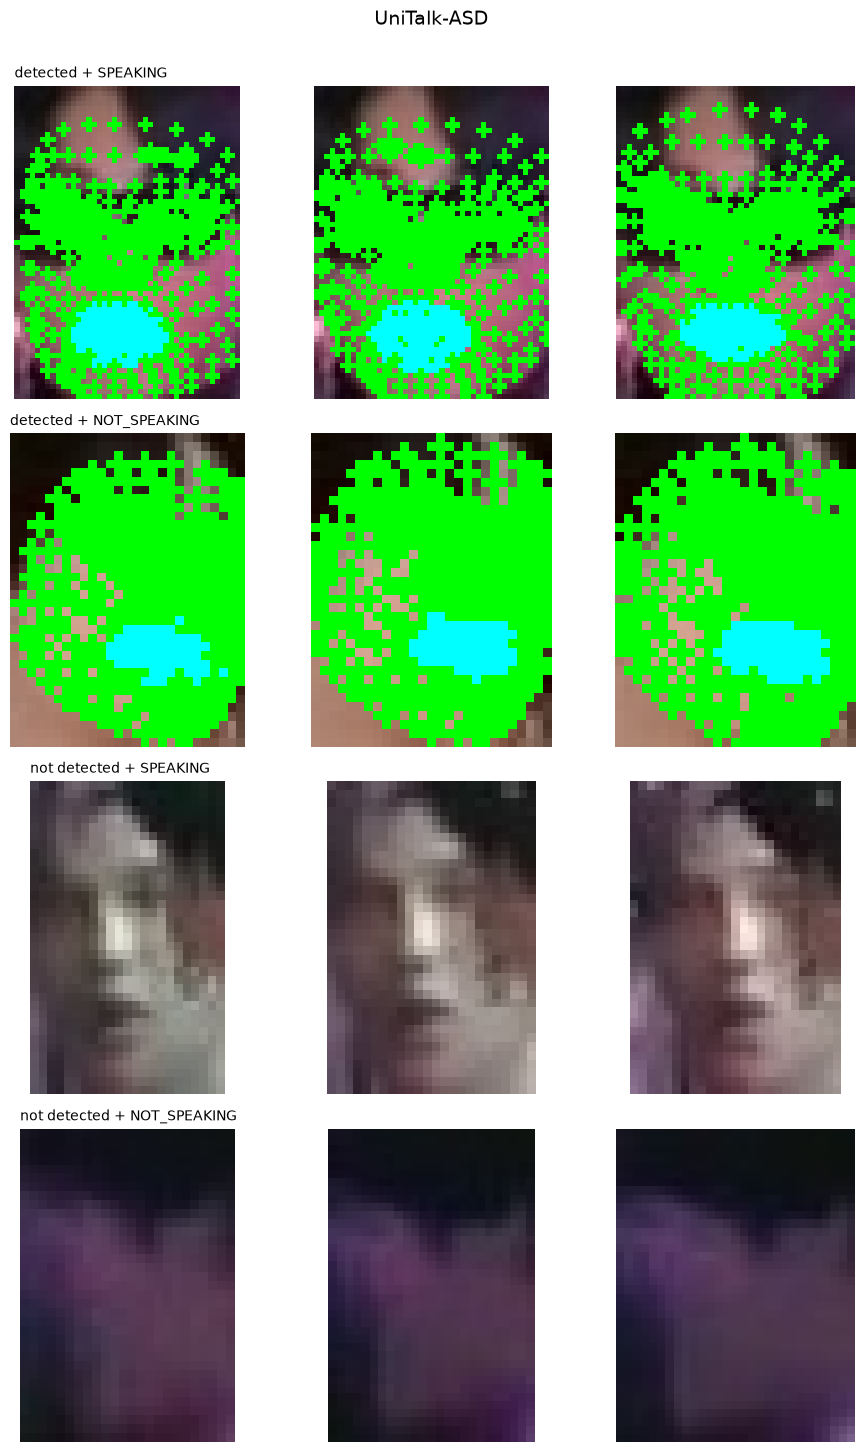

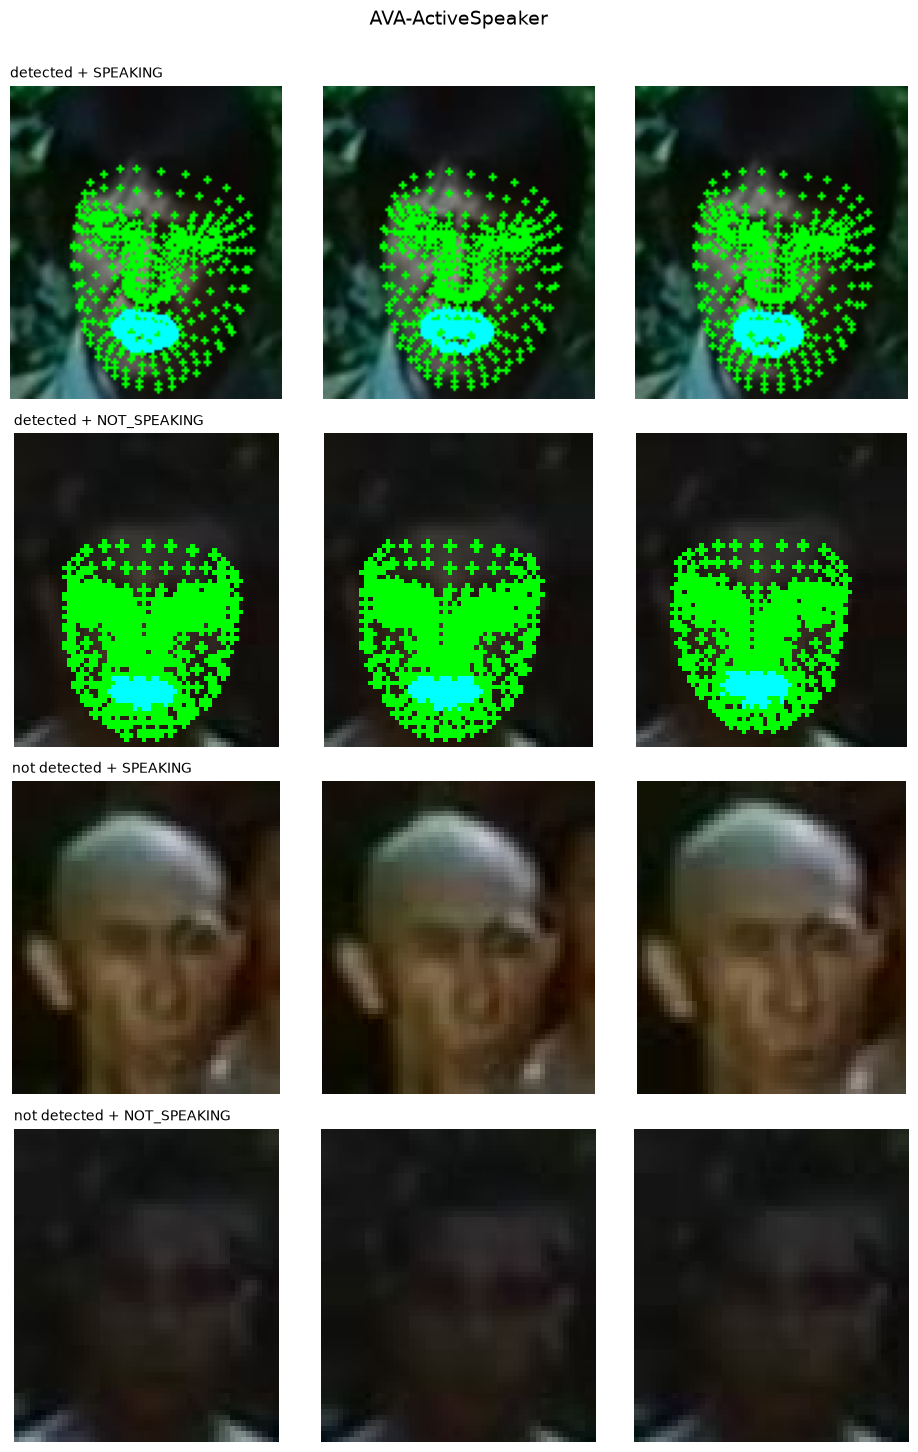

In [7]:
def show_grid(name: str, cfg: dict):
    rows_per_cat = N_PER_CATEGORY
    fig, axes = plt.subplots(len(CATEGORIES), rows_per_cat, figsize=(3.2 * rows_per_cat, 3.6 * len(CATEGORIES)))
    fig.suptitle(name, fontsize=14, y=1.005)

    for r, cat in enumerate(CATEGORIES):
        for c in range(rows_per_cat):
            ax = axes[r, c]
            ax.axis("off")
            rows = examples[name][cat]
            if c >= len(rows):
                continue
            row = rows[c]
            path = image_path(cfg["raw_dir"], "train", row)
            if not path.exists():
                ax.set_title("(missing file)", fontsize=8)
                continue
            if row["detected"]:
                img, detected = draw_landmarks(path)
                if not detected:
                    ax.set_title("(re-detect miss)", fontsize=8)
            else:
                img = Image.open(path).convert("RGB")
            ax.imshow(img)
            if c == 0:
                ax.set_title(CATEGORY_LABELS[cat], fontsize=10, loc="left")

    fig.tight_layout()
    plt.show()


for name, cfg in DATASETS.items():
    show_grid(name, cfg)